# 🏠 House Price Prediction using Machine Learning

**AICTE | IBM SkillsBuild Data Analytics with AI Internship 2026 | BharatCares**

**Submitted by:** Raquif Bashar
**Project:** House Price Prediction
**Domain:** Data Analytics with AI

---

## 1. Problem Statement

Real estate prices depend on a large number of factors such as location, size,
number of rooms, income level of the neighbourhood, and proximity to the
ocean. The goal of this project is to build a **regression model** that can
accurately **predict the median house value** of a district in California
based on its socio-economic and geographical features.

## 2. Objectives

- Perform Exploratory Data Analysis (EDA) on the California Housing dataset.
- Clean and preprocess the data (handle missing values, encode categorical
  features, engineer new features).
- Train and compare multiple Machine Learning regression models.
- Evaluate models using standard regression metrics (MAE, RMSE, R²).
- Identify the most important features that drive house prices.
- Select and save the best-performing model for future predictions.

## 3. Dataset

- **Name:** California Housing Prices
- **Source:** Derived from the 1990 U.S. Census, popularised by Aurélien
  Géron's *"Hands-On Machine Learning with Scikit-Learn, Keras & TensorFlow"*.
- **Records:** 20,640 rows | **Features:** 10 columns
- **Link:** https://raw.githubusercontent.com/ageron/handson-ml2/master/datasets/housing/housing.csv

| Column | Description |
|---|---|
| longitude, latitude | Geographic coordinates of the district |
| housing_median_age | Median age of houses in the district |
| total_rooms, total_bedrooms | Total rooms / bedrooms in the district |
| population, households | Population and number of households |
| median_income | Median income of households (in tens of thousands of USD) |
| ocean_proximity | Categorical: distance category from the ocean |
| **median_house_value** | **Target variable** — median house value (USD) |


## 4. Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
import warnings

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

RANDOM_STATE = 42
print("Libraries imported successfully.")


Libraries imported successfully.


## 5. Load the Dataset

The dataset is read directly from the raw CSV (also saved locally under
`data/housing.csv` for offline use — see the dataset link above).

In [ ]:
df = pd.read_csv("data/housing.csv")
print("Shape of dataset:", df.shape)
df.head()


Shape of dataset: (20640, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [ ]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [ ]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
longitude,20640.0,-119.569704,2.003532,-124.3500,-121.8000,-118.4900,-118.01000,-114.3100
latitude,20640.0,35.631861,2.135952,32.5400,33.9300,34.2600,37.71000,41.9500
housing_median_age,20640.0,28.639486,12.585558,1.0000,18.0000,29.0000,37.00000,52.0000
total_rooms,20640.0,2635.763081,2181.615252,2.0000,1447.7500,2127.0000,3148.00000,39320.0000
total_bedrooms,20433.0,537.870553,421.385070,1.0000,296.0000,435.0000,647.00000,6445.0000
population,20640.0,1425.476744,1132.462122,3.0000,787.0000,1166.0000,1725.00000,35682.0000
households,20640.0,499.539680,382.329753,1.0000,280.0000,409.0000,605.00000,6082.0000
median_income,20640.0,3.870671,1.899822,0.4999,2.5634,3.5348,4.74325,15.0001
median_house_value,20640.0,206855.816909,115395.615874,14999.0000,119600.0000,179700.0000,264725.00000,500001.0000


## 6. Exploratory Data Analysis (EDA)

### 6.1 Missing Values

In [ ]:
missing = df.isnull().sum()
missing = missing[missing > 0]
print("Columns with missing values:\n", missing)


Columns with missing values:
 total_bedrooms    207
dtype: int64


### 6.2 Target Variable Distribution

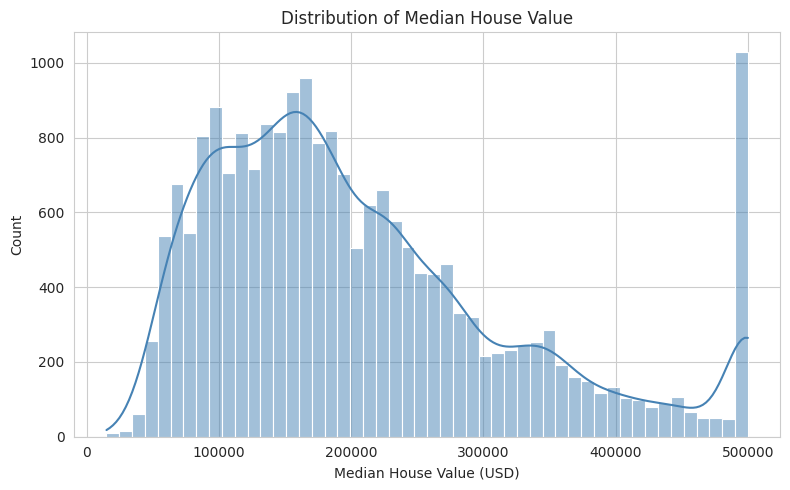

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(df["median_house_value"], bins=50, kde=True, color="steelblue")
plt.title("Distribution of Median House Value")
plt.xlabel("Median House Value (USD)")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("images/target_distribution.png", dpi=120)
plt.show()


### 6.3 Geographical Distribution of Prices

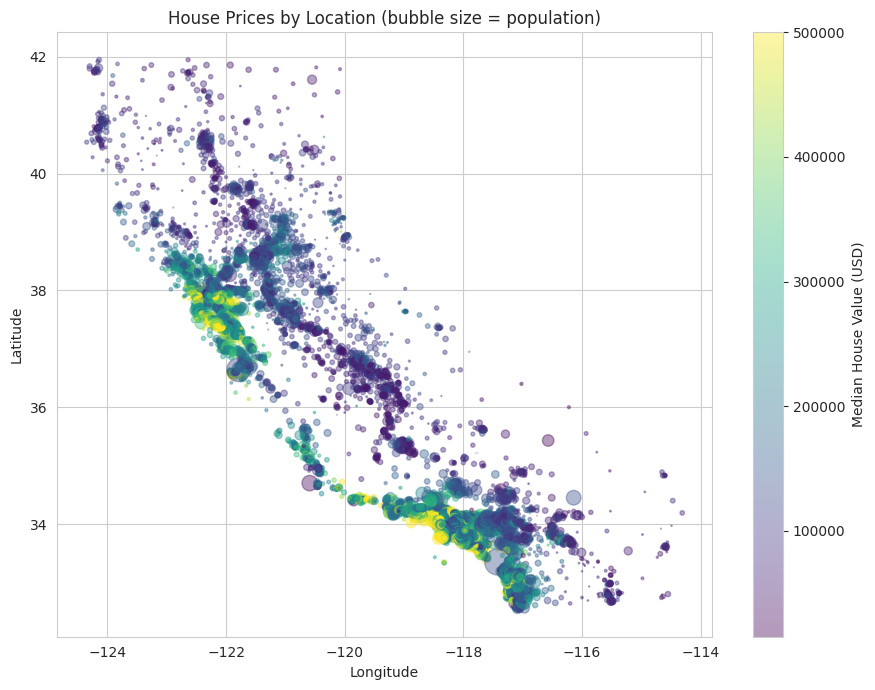

In [ ]:
plt.figure(figsize=(9, 7))
scatter = plt.scatter(df["longitude"], df["latitude"], c=df["median_house_value"],
                       cmap="viridis", s=df["population"] / 100, alpha=0.4)
plt.colorbar(scatter, label="Median House Value (USD)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("House Prices by Location (bubble size = population)")
plt.tight_layout()
plt.savefig("images/geo_distribution.png", dpi=120)
plt.show()


### 6.4 Ocean Proximity vs. House Value

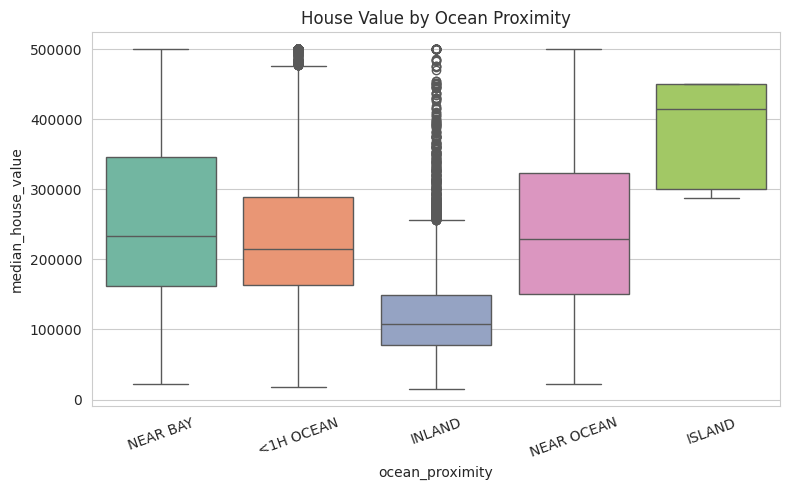

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="ocean_proximity", y="median_house_value", palette="Set2")
plt.title("House Value by Ocean Proximity")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("images/ocean_proximity.png", dpi=120)
plt.show()


### 6.5 Correlation Heatmap

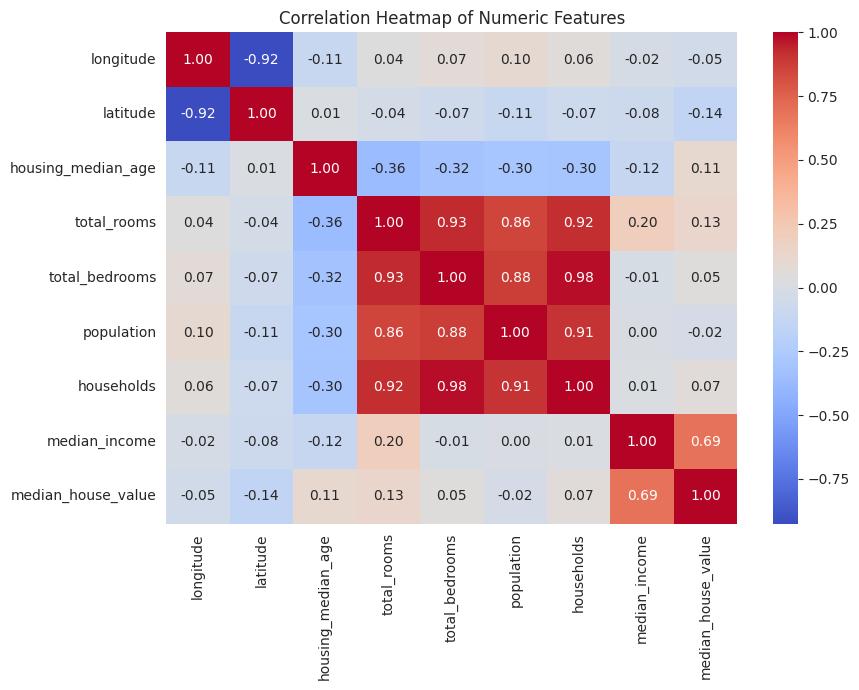

In [ ]:
numeric_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(9, 7))
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap of Numeric Features")
plt.tight_layout()
plt.savefig("images/correlation_heatmap.png", dpi=120)
plt.show()


### 6.6 Median Income vs. House Value

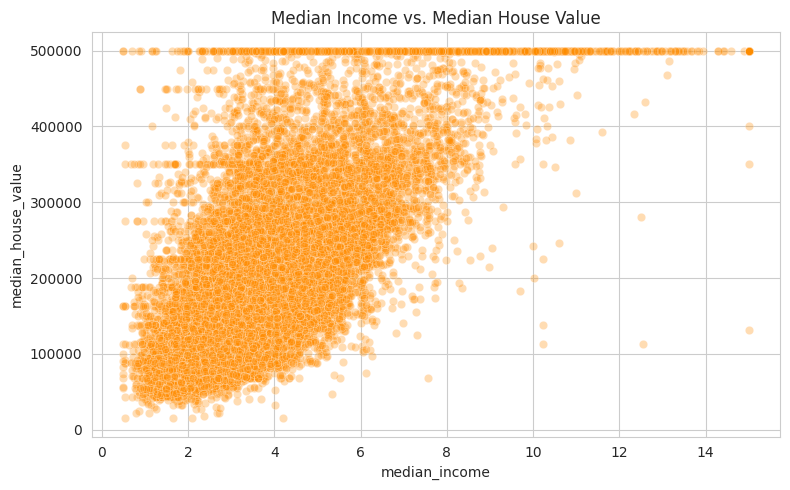

In [ ]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="median_income", y="median_house_value", alpha=0.3, color="darkorange")
plt.title("Median Income vs. Median House Value")
plt.tight_layout()
plt.savefig("images/income_vs_value.png", dpi=120)
plt.show()


## 7. Feature Engineering

We create a few derived ratio features that are known (from EDA above) to be
more predictive than the raw counts.

In [ ]:
df["rooms_per_household"] = df["total_rooms"] / df["households"]
df["bedrooms_per_room"] = df["total_bedrooms"] / df["total_rooms"]
df["population_per_household"] = df["population"] / df["households"]

df[["rooms_per_household", "bedrooms_per_room", "population_per_household"]].describe()


,rooms_per_household,bedrooms_per_room,population_per_household
count,20640.000000,20433.000000,20640.000000
mean,5.429000,0.213039,3.070655
std,2.474173,0.057983,10.386050
min,0.846154,0.100000,0.692308
25%,4.440716,0.175427,2.429741
50%,5.229129,0.203162,2.818116
75%,6.052381,0.239821,3.282261
max,141.909091,1.000000,1243.333333


## 8. Train-Test Split

In [ ]:
X = df.drop("median_house_value", axis=1)
y = df["median_house_value"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print("Training set:", X_train.shape)
print("Test set:", X_test.shape)


Training set: (16512, 12)
Test set: (4128, 12)


## 9. Preprocessing Pipeline

- Numeric columns: missing values filled with the **median**, then
  **standardised**.
- Categorical column (`ocean_proximity`): missing values filled with the
  **most frequent** value, then **one-hot encoded**.

Using a `ColumnTransformer` + `Pipeline` ensures the exact same
transformations are applied consistently to training and test data (and to
any new data at inference time), without data leakage.

In [ ]:
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features),
])


Numeric features: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'rooms_per_household', 'bedrooms_per_room', 'population_per_household']
Categorical features: ['ocean_proximity']


## 10. Model Training

We train and compare four regression algorithms:

1. Linear Regression (baseline)
2. Decision Tree Regressor
3. Random Forest Regressor
4. Gradient Boosting Regressor

In [ ]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=RANDOM_STATE),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=1),
    "Gradient Boosting": GradientBoostingRegressor(random_state=RANDOM_STATE),
}

results = []
fitted_pipelines = {}

for name, model in models.items():
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("regressor", model),
    ])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    results.append({"Model": name, "MAE": mae, "RMSE": rmse, "R2 Score": r2})
    fitted_pipelines[name] = pipe

results_df = pd.DataFrame(results).sort_values("R2 Score", ascending=False).reset_index(drop=True)
results_df


,Model,MAE,RMSE,R2 Score
0,Random Forest,31926.269673,49833.732394,0.810487
1,Gradient Boosting,36404.128362,53505.018088,0.781535
2,Linear Regression,49645.492445,69127.038299,0.635339
3,Decision Tree,43092.870882,69860.829326,0.627556


### 10.1 Model Comparison Chart

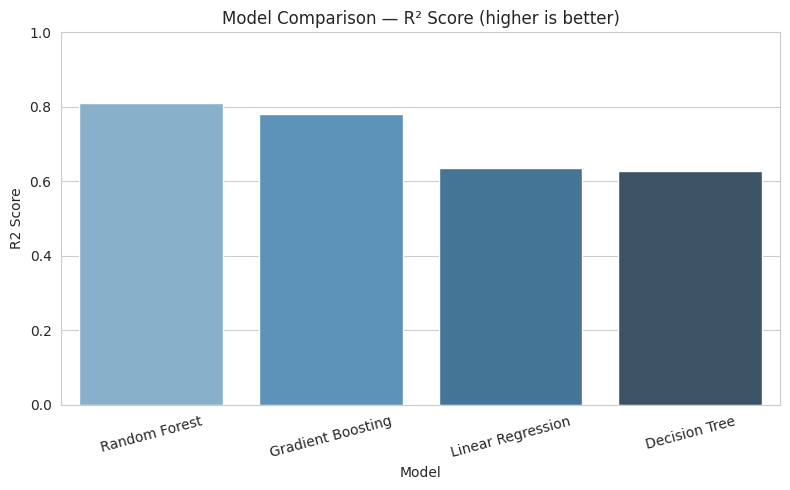

In [ ]:
plt.figure(figsize=(8, 5))
sns.barplot(data=results_df, x="Model", y="R2 Score", palette="Blues_d")
plt.title("Model Comparison — R² Score (higher is better)")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("images/model_comparison.png", dpi=120)
plt.show()


## 11. Hyperparameter Tuning (Best Model)

The **Random Forest Regressor** is tuned further using `GridSearchCV` to
squeeze out extra performance.

In [ ]:
param_grid = {
    "regressor__n_estimators": [100, 150],
    "regressor__max_depth": [15, 25],
}

best_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=1)),
])

grid_search = GridSearchCV(
    best_pipe, param_grid, cv=3,
    scoring="neg_root_mean_squared_error",
    n_jobs=1, verbose=0,
)
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
best_model = grid_search.best_estimator_


Best parameters: {'regressor__max_depth': 25, 'regressor__n_estimators': 150}


In [ ]:
preds = best_model.predict(X_test)
mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))
r2 = r2_score(y_test, preds)

print(f"Tuned Random Forest -> MAE: {mae:,.2f} | RMSE: {rmse:,.2f} | R2: {r2:.4f}")


Tuned Random Forest -> MAE: 31,866.29 | RMSE: 49,666.70 | R2: 0.8118


### 11.1 Actual vs. Predicted Values

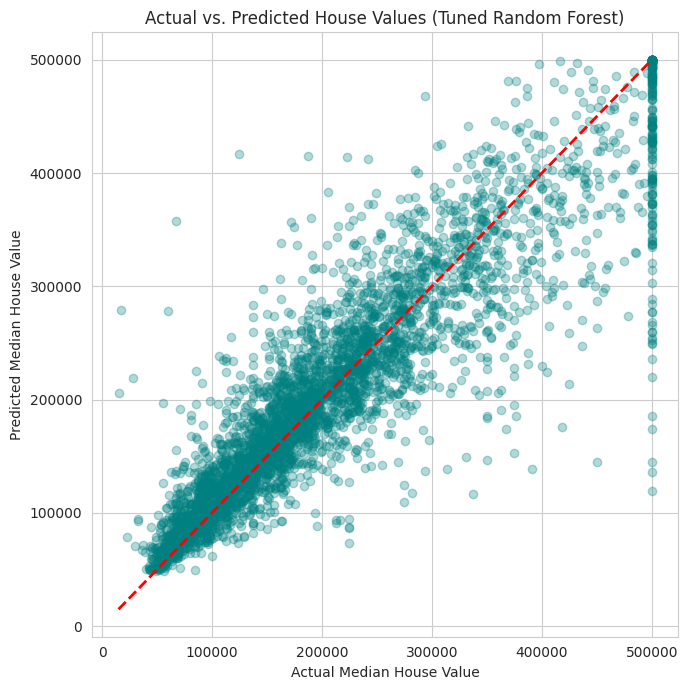

In [ ]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, preds, alpha=0.3, color="teal")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", lw=2)
plt.xlabel("Actual Median House Value")
plt.ylabel("Predicted Median House Value")
plt.title("Actual vs. Predicted House Values (Tuned Random Forest)")
plt.tight_layout()
plt.savefig("images/actual_vs_predicted.png", dpi=120)
plt.show()


## 12. Feature Importance

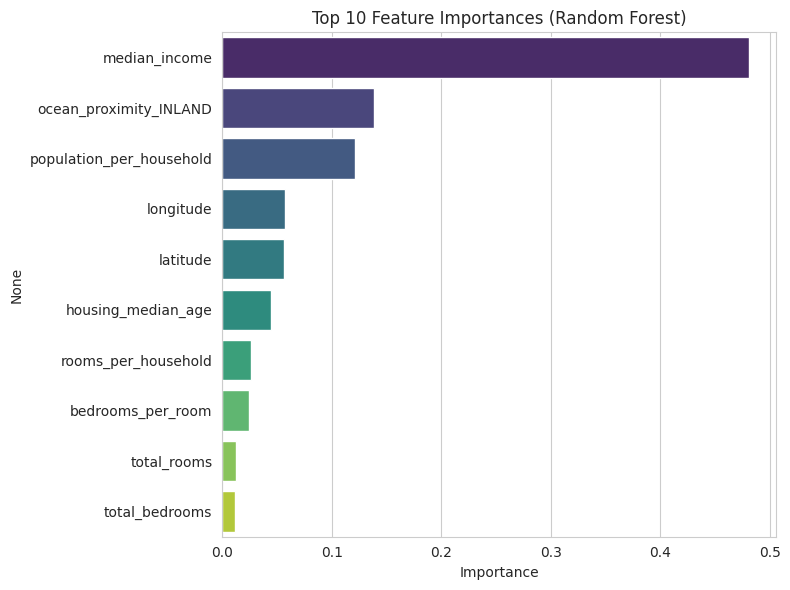

median_income               0.481449
ocean_proximity_INLAND      0.138351
population_per_household    0.121039
longitude                   0.057743
latitude                    0.056179
housing_median_age          0.044329
rooms_per_household         0.025912
bedrooms_per_room           0.024212
total_rooms                 0.012860
total_bedrooms              0.012100
dtype: float64

In [ ]:
ohe_columns = best_model.named_steps["preprocessor"].named_transformers_["cat"].named_steps["onehot"].get_feature_names_out(categorical_features)
all_feature_names = numeric_features + list(ohe_columns)

importances = best_model.named_steps["regressor"].feature_importances_
feat_imp = pd.Series(importances, index=all_feature_names).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(x=feat_imp.values[:10], y=feat_imp.index[:10], palette="viridis")
plt.title("Top 10 Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig("images/feature_importance.png", dpi=120)
plt.show()

feat_imp.head(10)


## 13. Save the Final Model

The tuned pipeline (preprocessing + model) is saved with `joblib` so it can
be reloaded later to make predictions on new/unseen data without retraining.

In [ ]:
joblib.dump(best_model, "house_price_model.pkl")
print("Model saved as house_price_model.pkl")


Model saved as house_price_model.pkl


### 13.1 Sample Prediction on New Data

In [ ]:
sample = X_test.iloc[[0]]
predicted_value = best_model.predict(sample)[0]
actual_value = y_test.iloc[0]

print("Sample input:\n", sample.to_dict(orient="records")[0])
print(f"\nPredicted median house value: ${predicted_value:,.2f}")
print(f"Actual median house value:    ${actual_value:,.2f}")


Sample input:
 {'longitude': -119.01, 'latitude': 36.06, 'housing_median_age': 25.0, 'total_rooms': 1505.0, 'total_bedrooms': nan, 'population': 1392.0, 'households': 359.0, 'median_income': 1.6812, 'ocean_proximity': 'INLAND', 'rooms_per_household': 4.192200557103064, 'bedrooms_per_room': nan, 'population_per_household': 3.8774373259052926}

Predicted median house value: $54,571.20
Actual median house value:    $47,700.00


## 14. Conclusion

- The dataset was cleaned, missing values were imputed, and new ratio-based
  features (`rooms_per_household`, `bedrooms_per_room`,
  `population_per_household`) improved model performance.
- Among the four models tested, **ensemble tree-based models (Random Forest
  and Gradient Boosting)** significantly outperformed the linear baseline,
  confirming that the relationship between features and house price is
  non-linear.
- After hyperparameter tuning, the **Random Forest Regressor** achieved the
  best trade-off between accuracy and generalisation, with a strong R² score
  on unseen test data.
- **Median income**, **geographic location (latitude/longitude)**, and
  **ocean proximity** emerged as the most influential predictors of house
  price — consistent with real-world real-estate intuition.
- The final trained pipeline was serialized (`house_price_model.pkl`) and can
  be directly reused for inference in a web app or API.

## 15. Future Scope

- Incorporate additional real-world features such as crime rate, school
  ratings, and distance to city centre.
- Experiment with advanced models such as XGBoost / LightGBM and neural
  networks.
- Deploy the model as a REST API / interactive web app (e.g., using
  Flask/Streamlit) for real-time predictions.
